In [98]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cbook, cm
from matplotlib.colors import LightSource

%matplotlib inline

## Problem 1: Steepest Descent
As a test function, we use

$$
f({\bf x}) = 2e^{x_{1}-.1}\cosh(3x_{2}) + e^{-x_{1}-.1}, ~ {\bf x} = (x_{1}, x_{2})
$$

One can quickly show that this has a global minimum at ${\bf x}_{\ast} = (-.5\ln(2), 0)$, and $f({\bf x}_{\ast})=2.5592666966582156$

In [99]:
def cvx_fun_plot(x1vals, x2vals):
    ex = np.exp(x1vals - .1)
    enx = np.exp(-x1vals - .1)
    ey = 2.*np.cosh(3.*x2vals)
    fun = ey[:, np.newaxis] @ ex[np.newaxis, :] + np.ones((x2vals.size,1)) @ enx[np.newaxis, :]
    return fun

In [100]:
def cvx_fun(xval):
    x1, x2 = xval[0], xval[1]
    return 2.*np.exp(x1-.1)*np.cosh(3.*x2) + np.exp(-x1-.1)

In [101]:
def grad_cvx_fun(xval):
    x1, x2 = xval[0], xval[1]
    gvec = np.zeros(2, dtype=np.float64)
    gvec[0] = 2. * np.exp(x1-.1) * np.cosh(3.*x2) - np.exp(-x1-.1)
    gvec[1] = 6. * np.exp(x1-.1) * np.sinh(3.*x2)
    return gvec

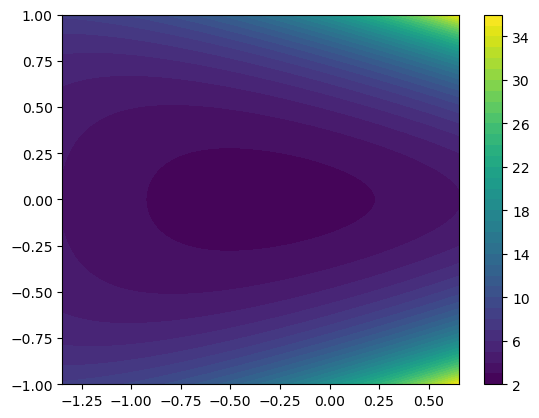

In [102]:
xstr = .5 * np.log(.5)
ystr = 0.
xvals = np.linspace(xstr - 1., xstr + 1., int(1e2)+1)
yvals = np.linspace(ystr - 1., ystr + 1., int(1e2)+1)
test_fun = cvx_fun_plot(xvals, yvals)
plt.contourf(xvals, yvals, test_fun, levels=40)
plt.colorbar();

Implement the steepest-descent update formula 

$$
{\bf x}_{k+1} = {\bf x}_{k} - \mu_{k}\nabla f({\bf x}_{k}), ~ \mu_{k} > 0
$$

with the convergence constraints

$$
f({\bf x}_{k+1}) \lt f({\bf x}_{k}), ~ \sum_{k=0}^{\infty}\mu_{k}=\infty, ~ \sum_{k=0}^{\infty}\mu^{2}_{k}\lt \infty.
$$

Given some user defined tolerance, say `tol`, we iterate until 

$$
\left|\left|\nabla f({\bf x}_{k})\right|\right| \lt \text{tol}.
$$

Choosing 100 initial conditions from the circle

$$
(x_{1} + .5\ln(2))^{2} + x_{2}^{2} = 1
$$

plot the iteration count as a function of the angle along your circle of initial conditions.  Commment on the performance of your implementation in particular with regards to how you choose your update scheme for $\mu_k$ and also how you choose your tolerance.  


In [103]:
def grad_step(xval, gvec, muval):
    return xval - muval * gvec

def steepest_descent(x0, tol):
    mu0 = mu_k = 1.
    cnt = 0.
    x1tst = grad_step(x0, grad_cvx_fun(x0), mu0)
    k = 1

    while np.linalg.norm(grad_cvx_fun(x0)) > tol: 
        # search along gradient to find a proper descent direction
        x1tst = x0 - mu0 * grad_cvx_fun(x0)

        while cvx_fun(x1tst) >= cvx_fun(x0):
            # what are you gonna do?
            k += 1
            mu_k = 1 / (k**0.75)
            x1tst = x0 - mu_k * grad_cvx_fun(x0)

        x0 = x1tst
        cnt += 1
        
        # How are we going to update our steps to fit with our convergence requirements?  
        mu0 = mu_k # what are you gonna do?  
        
    return x0, cnt

def steep_descent_tester(num_angles, tol):
    x1str = .5 * np.log(.5)
    x2str = 0.
    
    angles = np.linspace(0, 2.*np.pi, num_angles)
    counts = np.zeros(num_angles, dtype=int)
    for jj in range(num_angles):
        x0 = np.array([ x1str + np.cos(angles[jj]), x2str + np.sin(angles[jj]) ]) 
        xstr, cnt = steepest_descent(x0, tol)
        counts[jj] = cnt

    fig, ax = plt.subplots(figsize=(7, 4))

    plt.plot(angles, counts)
    plt.ylabel("Number of Iterations to Converge")
    plt.xlabel("Initial Angle")

    custom_ticks = [0, np.pi/4, np.pi/2, (3*np.pi)/4, np.pi, (5*np.pi)/4, (3*np.pi)/2, (7*np.pi)/4, 2*np.pi]
    custom_tick_labels = ['$0$', '$\pi/4$', '$\pi/2$', '$3\pi/4$', '$\pi$', '$5\pi/4$', '$3\pi/2$', '$7\pi/4$', '$2\pi$']

    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_tick_labels)

    plt.grid()


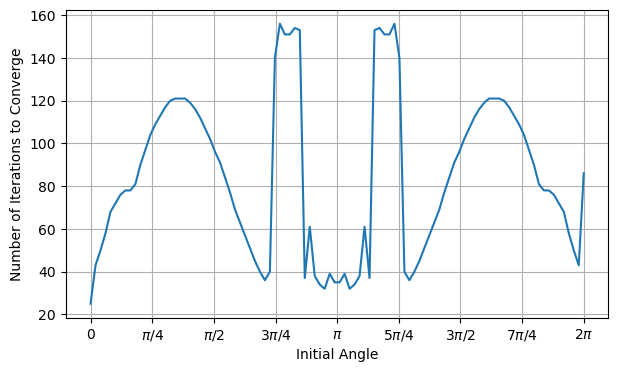

In [51]:
steep_descent_tester(100, 1e-6)

Tell me a story :)

This plot shows the relationship between the chosen initial angle and the number of iterations the algorithm takes to converge. It mirrors when reflected over $x = \pi$, and comes to a maximum right around $\frac{3\pi}{4} / \frac{5\pi}{4}$, where we see a very large jump. This is likely because the gradient at that value is nearly critical in either of the gradient functions, since one contains $cosh(x)$ and the other $sinh(x)$.

## Problem 2: Momentum to Accelerate Convergence

So we can imagine that as the steepest descent method starts to converge onto a minimum of $f({\bf x})$, it faces a landscape in which $\nabla f({\bf x})$ doesn't change much from iteration to iteration.  To take advantage of this, we add what is called *momentum* to our steepest descent update formula.  This looks like the following algorithm.

\begin{align*}
\Delta {\bf x}_{k+1} =  & a\Delta {\bf x}_{k} - \mu \nabla f({\bf x}_{k})\\
{\bf x}_{k+1} = & {\bf x}_{k} + \Delta {\bf x}_{k+1}.
\end{align*}

Here, $0<a<1$ is the *momentum term* and we now fix the step $\mu$ to be a constant (though we still need to make sure we're taking descent directions so we need to be careful about choices for this parameter).  Since $\mu$ is now a constant, we call it the *learning rate* of our descent method.    

* Show that over some **very large** number of iterations such that $\nabla f({\bf x}_{k})\approx {\bf c}$, we can solve for $\Delta {\bf x}$ so that
$$
\Delta {\bf x} \approx -\frac{\mu}{1-a}{\bf c}
$$

$$
\nabla f({\bf x}_{k}) \approx c
$$

$$
\rightarrow \Delta x_{k+1} = a\Delta x_{k} - \mu \bf{c}
$$

$$
\Delta x_{k+1} = a\left(a\Delta x_{k-1} - \mu c \right) - \mu c = a^2 \Delta x_{k-1} - \mu \left(c + ac\right)
$$
$$
...
$$

$$
\Delta x_{k+1} = a^k \Delta x_{0} - \mu \sum_{j=0}^{k-1} a^{j} c = a^k \Delta x_{0} - \mu \left(\frac{1 - a^k}{1 - a}\right)c
$$

And as $k \to \infty$, $a^k \to 0$ since $0 < a < 1$, so we have 

$$
\Delta x \approx \lim_{k\to\infty} \Delta x_{k} = -\frac{\mu}{1 - a}c
$$
* What effect does the momentum then have on your method?  Why does adding momentum in effect automatically make your method have an adaptive step-size?

Since the $\Delta x$ term can be written in terms of $a$ and $\mu$, if the gradient is acting roughly the same for a number of iterations, the $\Delta x$ value at the current step will effectively scale the learning rate by $\frac{1}{1 - a}$ and make the step size larger (leading to faster convergence). In the case of a sign flip across iterations (indicitave of a valley), the past $a\Delta x$ term will partially cancel out the $-\mu \nabla f(x_{k})$ term, which shrinks the step size and helps it pinpoint the valley.

* To implement this method, we suppose that $\Delta {\bf x}_{0}=0$ and we then make a choice of $a$ and $\mu$.  Code this up and explore how the iteration counts can be improved by using different choices of $\mu$ and $a$.  

In [104]:
def momentum_solver(a, mu, xj, dxj):
    dxjp1 = a * dxj - mu * grad_cvx_fun(xj)
    xjp1 = xj + dxjp1
    return xjp1, dxjp1
    
def momentum_tester(num_angles, a, mu, tol):
    x1str = .5 * np.log(.5)
    x2str = 0.
    
    angles = np.linspace(0, 2.*np.pi, num_angles)
    counts = np.zeros(num_angles, dtype=int)
    
    for jj in range(num_angles):
        x0 = np.array([ x1str + np.cos(angles[jj]), x2str + np.sin(angles[jj]) ]) 
        dx0 = np.zeros(2, dtype=np.float64)    
        x1, dx1 = momentum_solver(a, mu, x0, dx0)
        cnt = 0
        while np.linalg.norm(x1-x0) >= tol * np.linalg.norm(x0):
            x0, dx0 = x1, dx1
            x1, dx1 = momentum_solver(a, mu, x0, dx0)
            cnt += 1
        
        counts[jj] = cnt

    return counts

In [105]:
angles, tol = 100, 1e-6

pairs = [
    (0.20, 0.05),
    (0.20, 0.10),
    (0.20, 0.20),
    (0.40, 0.05),
    (0.40, 0.10),
    (0.40, 0.20),
]

i=1
for a, mu in pairs:
    counts = momentum_tester(angles, a, mu, tol)
    print(f"{i}) a={a:.2f}, mu={mu:.2f} | min iters={int(np.min(counts))}, max={int(np.max(counts))}, "
          f"avg={np.mean(counts):.1f}")
    i+=1


1) a=0.20, mu=0.05 | min iters=5, max=78, avg=68.8
2) a=0.20, mu=0.10 | min iters=2, max=34, avg=15.7
3) a=0.20, mu=0.20 | min iters=2, max=101, avg=25.5
4) a=0.40, mu=0.05 | min iters=33, max=46, avg=42.4
5) a=0.40, mu=0.10 | min iters=2, max=35, avg=16.3
6) a=0.40, mu=0.20 | min iters=2, max=34, avg=10.1


C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:4: RuntimeWarning: overflow encountered in cosh
  gvec[0] = 2. * np.exp(x1-.1) * np.cosh(3.*x2) - np.exp(-x1-.1)
C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:4: RuntimeWarning: invalid value encountered in scalar multiply
  gvec[0] = 2. * np.exp(x1-.1) * np.cosh(3.*x2) - np.exp(-x1-.1)
C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:4: RuntimeWarning: overflow encountered in exp
  gvec[0] = 2. * np.exp(x1-.1) * np.cosh(3.*x2) - np.exp(-x1-.1)
C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:5: RuntimeWarning: overflow encountered in sinh
  gvec[1] = 6. * np.exp(x1-.1) * np.sinh(3.*x2)
C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  gvec[1] = 6. * np.exp(x1-.1) * np.sinh(3.*x2)
C:\Users\Scotty\AppData\Local\Temp\ipykernel_11580\3942078257.py:4: RuntimeWarning: invalid value encountered in 

Tell me a story :)

It looks like the ratio of the $a$ and $\mu$ values are the main factors at play here, which makes sense since they are being directly compared in the fraction that approximates $\Delta x_{k}$. A high $a$ to $\mu$ ratio results in a higher number of max iterations and a higher average as well. What's interesting though is that pairs 2 and 6, while having the same ratio, differ in average number of iterations. But even then pairs 1 and 5 have the same ratios but different results all across the board. This relationship is very interesting and while there is somewhat of a pattern, I sense there's something larger at play, more under the hood, that is to be seen.

## Problem 3 (Graduate): Epigraphs

For a function $f:\mathbb{R}^{n}\rightarrow \mathbb{R}$, we define its *epigraph* $\text{epi}(f;C)$ to be 

$$
\text{epi}(f;C) = \left\{ ({\bf x}, r)\in C \times \mathbb{R}: ~ f({\bf x}) \leq r \right\},
$$

where $C\subset \mathbb{R}^{n}$ is convex.  Show that $f$ is a convex function if and only if $\text{epi}(f)$ is a convex subset of $\mathbb{R}^{n}\times \mathbb{R}$.

## Problem 4 (Graduate): $l_{1}$-norms and Sparsity

Suppose that, for ${\bf y}, {\bf z} \in \mathbb{R}^{n}$ we want to solve 

$$
{\bf z}_{\ast} = \text{arg min}_{{\bf z}} ~ \left|\left|{\bf y} - A{\bf z}\right|\right|_{2}^{2} + \lambda \left|\left|{\bf z}\right|\right|_{1} + \gamma \left|\left|{\bf z}\right|\right|_{2}^{2}
$$

where $\lambda, ~ \gamma > 0$ and for real-valued, square $A$ such that $A^{T}A = AA^{T} = I$.  Letting ${\bf u} = A^{T}{\bf y}$, show that 

$$
z_{\ast,l} = \left\{
\begin{array}{rl}
\frac{1}{1+\gamma}\left(u_{l} - \frac{\lambda}{2}\right) & u_{l} > \frac{\lambda}{2} \\
0 & |u_{l}| \leq \frac{\lambda}{2} \\ 
\frac{1}{1+\gamma}\left(u_{l} + \frac{\lambda}{2}\right) & u_{l} < -\frac{\lambda}{2} 
\end{array}
\right.
$$

Show that this multi-part formula can be written in the freakishly compact form

$$
z_{\ast,l} = \frac{u_{l}}{1+\gamma}\text{max}\left\{0, 1 - \frac{\lambda}{2|u_{l}|}\right\}
$$

Note, to do all of this, you'll need the sub-differential of $|x|$, $\partial |x|$, where 

$$
\partial |x| = \left\{
\begin{array}{rl}
1 & x > 0\\
r\in[-1,1]& x=0, ~ \\
-1 & x < 0
\end{array}
\right.
$$

What role then does the $l_{1}$-norm play in this problem and why?

## Problem 5: The Perceptron

In [106]:
# Let's make some data in R^3 for the Perceptron to classify.  
def hyperplane(x):
    return 1. + np.sum(np.ones(3) * x) # let's keep this simple
    
# Generate labeled data on either side of a 3D plane.
def label_maker(Npts, margin):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    points_above = []
    labels_plus = []    
    points_below = []
    labels_minus = []

    for jj in range(Npts):
        tst_point = 10.* np.random.randn(3)
        find = True
        while find:
            if hyperplane(tst_point) >= margin:
                points_above.append(tst_point)
                labels_plus.append(1)
                find = False
                ax.scatter(tst_point[0], tst_point[1], tst_point[2], c='k')
            elif hyperplane(tst_point) <= -margin:
                points_below.append(tst_point)
                labels_minus.append(-1)
                find = False
                ax.scatter(tst_point[0], tst_point[1], tst_point[2], c='r')
            else:
                tst_point = 10.* np.random.randn(3)

    xvals = np.linspace(-50., 50., int(1e1)+1)
    yvals = np.linspace(-50., 50., int(1e1)+1)
    xx, yy = np.meshgrid(xvals, yvals)
    zvals = -1 - xx - yy
    ax.plot_surface(xx, yy, zvals, linewidth=0, alpha=.25)
    return points_above, labels_plus, points_below, labels_minus

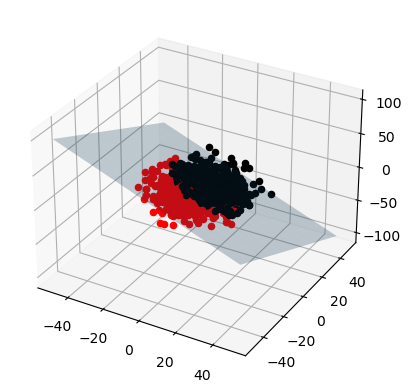

In [97]:
points_above, labels_plus, points_below, labels_minus = label_maker(1000, .01)

So, the Perceptron is the simplest neural network, which for labeled data $\left\{({\bf x}_{m},l_{m})\right\}_{m=1}^{N_{D}}$ is defined by the loss function:

$$
\tilde{\mathcal{L}}(\theta, b) = \frac{1}{N_{D}}\sum_{m=1}^{N_{D}}\text{max}\left(0, -l_{m}\left(b + \left<\theta,{\bf x}_{m}\right>\right)\right)
$$

To make the next bit of analysis more straightforward, define $\tilde{{\bf x}}_{m} = ({\bf x}_{m}, 1)$ and $\tilde{\theta} = (\theta, b)$ so that 
$$
\tilde{\mathcal{L}}(\theta, b) = \frac{1}{N_{D}}\sum_{m=1}^{N_{D}}\text{max}\left(0, -\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> \right)
$$

Likewise, define $\mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m}))$ as 
$$
\mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m})) = \text{max}\left(0, -\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> \right)
$$

**Part 1**: Show that $\partial_{\tilde{\theta}} \mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m}))$ is given by
$$
\partial_{\tilde{\theta}} \mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m})) = \left\{
    \begin{array}{rl}
    0 & \left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right>   \gt 0 \\
    & \\
    -l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> \lt 0\\
    & \\
    \frac{1}{2}(r-1)l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> = 0, ~ -1\leq r \leq 1
    \end{array}
    \right.
$$
To do this, remember that
$$
\mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m})) = -\frac{1}{2}\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> + \frac{1}{2}\left|\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> \right|
$$
and then remember back to how we differentiated $|x|$ and then use the chain rule.

From lecture notes:
$$
\partial_{\tilde{\theta}} \left<\tilde{\theta}, l_{m}\tilde{x}_{m}\right> = l_m \tilde{x}_m,
$$
$$
\partial_{\tilde{\theta}} \left|\left<\tilde{\theta}, l_{m}\tilde{x}_{m}\right>\right| = \left\{
    \begin{array}{rl}
    l_{m} x_{m} & \left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right>   \gt 0 \\
    & \\
    -l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> \lt 0\\
    & \\
    r l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> = 0, ~ -1\leq r \leq 1
    \end{array}
    \right.
$$

$$
\implies \partial_{\tilde{\theta}} \mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m})) = \partial_{\tilde{\theta}}\left(-\frac{1}{2}\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> + \frac{1}{2}\left|\left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right> \right|\right)
$$

$$
= -\frac{1}{2} l_{m} \tilde{x}_{m} + \partial_{\tilde{\theta}} \left( \frac{1}{2} \left|\left<\tilde{\theta}, l_{m}\tilde{x}_{m}\right>\right| \right)
$$

$$
= \left\{
    \begin{array}{rl}
    -\frac{1}{2} l_{m} \tilde{x}_{m} + \frac{1}{2} l_{m} \tilde{x}_{m} & \left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right>   \gt 0 \\
    & \\
    -\frac{1}{2} l_{m} \tilde{x}_{m} -\frac{1}{2} l_{m} \tilde{x}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> \lt 0\\
    & \\
    -\frac{1}{2} l_{m} \tilde{x}_{m} + \frac{1}{2} r l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> = 0, ~ -1\leq r \leq 1
    \end{array}
    \right.
$$

$$
= \left\{
    \begin{array}{rl}
    0 & \left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right>   \gt 0 \\
    & \\
    -l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> \lt 0\\
    & \\
    \frac{1}{2}(r-1)l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> = 0, ~ -1\leq r \leq 1
    \end{array}
    \right.
$$

**Part 2**: Choosing $r=-1$, show that the steepest-descent step becomes 

$$
\tilde{\theta}_{k+1} = \tilde{\theta}_{k} + \frac{\mu_{k}}{N_{D}}\sum_{m=1}^{N_{D}}l_{m}\tilde{{\bf x}}_{m} I_{(-\infty, 0]}\left(\left<\tilde{\theta}_{k},l_{m}\tilde{{\bf x}}_{m}\right>\right), ~ \mu_{k} \gt 0,
$$

where $I_{(-\infty, 0]}(t)$ is the indicator function.

For $r=-1$:

$$
\partial_{\tilde{\theta}} \mathcal{L}(\tilde{\theta}; (\tilde{{\bf x}}_{m}, l_{m})) = \left\{
    \begin{array}{rl}
    0 & \left<\tilde{\theta},l_{m}\tilde{{\bf x}}_{m}\right>   \gt 0 \\
    & \\
    -l_{m}\tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> \lt 0\\
    & \\
   -l_{m} \tilde{{\bf x}}_{m} & \left<\tilde{\theta},l_{m} \tilde{{\bf x}}_{m}\right> = 0
    \end{array}
    \right.
$$

Which we can rewrite as

$$
\tilde{\theta}_{k+1} = \tilde{\theta}_{k} - \mu_{k}\partial_{\tilde{\theta}} \mathcal{L}(\theta, b) = \tilde{\theta}_{k} + \frac{\mu_{k}}{N_D} \sum_{m=1}^{N_D} l_{m} \tilde{{\bf x}}_{m} I_{(-\infty, 0]}\left(\left<\tilde{\theta}_{k},l_{m}\tilde{{\bf x}}_{m}\right>\right)
$$

**Part 3**: Using the data generation method above, implement the steepest-descent method for the Perceptron.  Does the number of iterations the method takes to converge change based on your choice of $\mu_{k}$?

In [108]:
Nd = len(points_above) + len(points_below)
dim = points_above[0].size
data_mat = np.ones((dim+1, Nd))
data_mat[:dim, :len(points_above)] = np.array(points_above).T 
data_mat[dim, :len(points_above)] = 1. 
data_mat[:dim, len(points_above):] = -np.array(points_below).T
data_mat[dim, len(points_above):] = -1. 

In [113]:
def perceptron_step(theta0, data_mat, mu):
    innerp = (theta0.T @ data_mat).ravel()
    indskp = innerp <= 0.
    grad = np.sum(data_mat[:, indskp], axis=1) / data_mat.shape[1]
    theta1 = theta0 + mu*grad[:,np.newaxis]
    return theta1

In [114]:
mu = 1.
tol = 1e-3

theta0 = np.zeros((dim+1, 1), dtype=np.float64)
theta1 = perceptron_step(theta0, data_mat, mu)
cnt = 0

while np.linalg.norm(theta1-theta0) >= tol * np.linalg.norm(theta0):
    theta0 = theta1
    theta1 = perceptron_step(theta0, data_mat, mu)
    cnt += 1

print(theta1)
print(cnt)

[[3.7201448 ]
 [3.68561443]
 [3.72056172]
 [3.467     ]]
510


Tell me a story here :)

The output is the parameter vector that defines the separating hyperplane followed by the number of iterations it took to converge to our stopping criteria. It is the solution to the decision boundary equation $\theta^{\intercal} x + b = 0$, with $x_1$ through $x_3$ being the first 3 entries and then the last entry being $b$.